# EXP-009 | McLernon 2016 기반 피처 엔지니어링

**참고 논문**: McLernon DJ et al., *BMJ* 2016;355:i5735  
"Predicting the chances of a live birth after one or more complete cycles of in vitro fertilisation"

## 논문 핵심 발견 → 피처 설계 근거

| McLernon 발견 | OR / Adequacy | 데이터셋 매핑 | 새 피처 |
|---|---|---|---|
| 여성 나이 | AI=0.846 (1위) | `시술 당시 나이` | 기존 순서형 유지 |
| 동결 배아 보유 | OR=1.91 (최강) | `저장된 배아 수` | `동결배아_보유` |
| 채취 난자 수 (~13 최적, 비선형) | OR=1.29 | `수집된 신선 난자 수` | `난자수_최적거리`, `난자수_초과`, `난자수_부족` |
| 배반포 단계 이식 | OR=1.79 | `배아 이식 경과일` | `배반포_이식_여부` |
| ICSI 시술 | OR=1.24 | `특정 시술 유형` | `ICSI_여부` (pre-encode) |
| 불임 기간 짧을수록 유리 | OR=1.09 | `임신 시도 또는 마지막 임신 경과 연수` | `불임기간_단기` |
| 난관 불임 (부정적) | OR=0.91 | `불임 원인 - 난관 질환` | 기존 피처 유지 |
| 남성 불임 (부정적) | OR=0.90 | `불임 원인 - 남성 요인` | 기존 피처 유지 |

| 항목 | 내용 |
|---|---|
| 기반 실험 | EXP-003 피처 + McLernon 파생 피처 6개 추가 |
| 모델 | LightGBM (EXP-004 최적 파라미터 사용) |
| CV | Stratified 5-Fold |

In [7]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
from pathlib import Path
from datetime import date

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, recall_score, precision_score, accuracy_score
import lightgbm as lgb

from src.preprocessing import preprocess

warnings.filterwarnings('ignore')
font_path = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = Path('../data/raw')
OUT_DIR  = Path('../data/submissions')
DOCS_DIR = Path('../docs')
TARGET   = '임신 성공 여부'
SEED     = 42
N_FOLDS  = 5
EXP_NO   = 9
AUTHOR   = '조여진'
MODEL_NAME = 'LightGBM'
CV_STR   = f'Stratified {N_FOLDS}-Fold'

train = pd.read_csv(DATA_DIR / 'train.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')
sub   = pd.read_csv(DATA_DIR / 'sample_submission.csv')
print(f'train: {train.shape}  /  test: {test.shape}')

train: (256351, 69)  /  test: (90067, 68)


## 1. 피처 엔지니어링

### McLernon 신규 피처 (6개)
| 피처 | 계산식 | McLernon 근거 |
|---|---|---|
| `ICSI_여부` | 특정 시술 유형 == 'ICSI' | pre-treatment OR=1.24 |
| `난자수_최적거리` | \|수집된 신선 난자 수 - 13\| | 비선형 효과, ~13개 최적 |
| `난자수_초과` | max(0, 수집된 신선 난자 수 - 13) | 과배란 자극 부정적 영향 |
| `난자수_부족` | max(0, 13 - 수집된 신선 난자 수) | 저반응 부정적 영향 |
| `배반포_이식_여부` | 배아 이식 경과일 >= 5 | blastocyst 이식 OR=1.79 |
| `동결배아_보유` | 저장된 배아 수 > 0 | 동결 배아 보유 OR=1.91 (최강) |
| `불임기간_단기` | 임신 시도 경과 연수 <= 3 | 짧을수록 유리, OR=1.09 |

In [8]:
# ── Pre-encode 피처 (원본 문자열 필요) ──────────────────
def add_pre_encode_features(df):
    df = df.copy()
    # EXP-003 피처
    df['기증_난자_여부'] = (df['난자 출처'] == '기증 제공').astype(int)
    df['기증_정자_여부'] = df['정자 출처'].isin(
        ['기증 제공', '배우자 및 기증 제공']).astype(int)
    # McLernon: ICSI 시술 여부 (OR=1.24, pre-treatment predictor)
    df['ICSI_여부'] = df['특정 시술 유형'].str.upper().str.contains('ICSI', na=False).astype(int)
    return df


# ── Post-encode 파생 피처 ─────────────────────────────────
def add_derived_features(df):
    df = df.copy()
    eps = 1e-6

    # ── EXP-003 기존 피처 ──────────────────────────────────
    df['수정률']    = df['총 생성 배아 수']   / (df['혼합된 난자 수'] + eps)
    df['이식률']    = df['이식된 배아 수']    / (df['총 생성 배아 수'] + eps)
    df['저장률']    = df['저장된 배아 수']    / (df['총 생성 배아 수'] + eps)
    df['ICSI_비율'] = df['미세주입된 난자 수'] / (df['혼합된 난자 수'] + eps)
    df['배아_발달일']    = df['배아 이식 경과일'] - df['난자 혼합 경과일']
    df['신선_시술_여부']  = df['수집된 신선 난자 수'].notna().astype(int)

    male_cols   = ['남성 주 불임 원인','남성 부 불임 원인','불임 원인 - 남성 요인']
    female_cols = ['여성 주 불임 원인','여성 부 불임 원인','불임 원인 - 난관 질환',
                   '불임 원인 - 배란 장애','불임 원인 - 자궁내막증','불임 원인 - 자궁경부 문제']
    couple_cols = ['부부 주 불임 원인','부부 부 불임 원인']
    sperm_cols  = ['불임 원인 - 정자 농도','불임 원인 - 정자 운동성',
                   '불임 원인 - 정자 형태','불임 원인 - 정자 면역학적 요인']
    all_cause   = male_cols + female_cols + couple_cols + sperm_cols + ['불명확 불임 원인']
    df['남성_불임_합계']      = df[male_cols].sum(axis=1)
    df['여성_불임_합계']      = df[female_cols].sum(axis=1)
    df['부부_불임_합계']      = df[couple_cols].sum(axis=1)
    df['정자_문제_합계']      = df[sperm_cols].sum(axis=1)
    df['총_불임원인_수']      = df[all_cause].sum(axis=1)
    df['임신시도기록_있음']    = df['임신 시도 또는 마지막 임신 경과 연수'].notna().astype(int)
    df['신선_난자_저장_있음']  = (df['저장된 신선 난자 수'] > 0).astype(int)
    df['나이_시술횟수_상호작용'] = df['시술 당시 나이'] * df['총 시술 횟수']

    # ── McLernon 2016 기반 신규 피처 ──────────────────────
    # 채취 난자 수 비선형: ~13개 최적 (restricted cubic spline 대용)
    OPTIMAL_EGGS = 13
    egg_col = '수집된 신선 난자 수'
    df['난자수_최적거리'] = (df[egg_col] - OPTIMAL_EGGS).abs()
    df['난자수_초과']     = (df[egg_col] - OPTIMAL_EGGS).clip(lower=0)   # 과배란 자극
    df['난자수_부족']     = (OPTIMAL_EGGS - df[egg_col]).clip(lower=0)   # 저반응

    # 배반포 단계 이식 여부 (배아 이식 경과일 >= 5 → day5 blastocyst, OR=1.79)
    df['배반포_이식_여부'] = (df['배아 이식 경과일'] >= 5).astype(int)

    # 동결 배아 보유 여부 (McLernon: 가장 강한 post-treatment predictor, OR=1.91)
    df['동결배아_보유'] = (df['저장된 배아 수'] > 0).astype(int)

    # 불임 기간 단기 여부 (3년 이하 → 유리, McLernon OR=1.09)
    df['불임기간_단기'] = (df['임신 시도 또는 마지막 임신 경과 연수'] <= 3).astype(int)

    return df


# ── 전처리 파이프라인 ─────────────────────────────────────
train_fe = add_pre_encode_features(train)
test_fe  = add_pre_encode_features(test)
X_train, X_test = preprocess(train_fe, test_fe)
X_train = add_derived_features(X_train)
X_test  = add_derived_features(X_test)
y_train = train[TARGET]

mclernon_features = ['난자수_최적거리','난자수_초과','난자수_부족',
                     '배반포_이식_여부','동결배아_보유','불임기간_단기','ICSI_여부']
print(f'X_train: {X_train.shape}  /  X_test: {X_test.shape}')
print(f'McLernon 신규 피처 ({len(mclernon_features)}개): {mclernon_features}')

X_train: (256351, 92)  /  X_test: (90067, 92)
McLernon 신규 피처 (7개): ['난자수_최적거리', '난자수_초과', '난자수_부족', '배반포_이식_여부', '동결배아_보유', '불임기간_단기', 'ICSI_여부']


## 2. 모델 학습 (EXP-004 최적 파라미터 기반)

In [9]:
# EXP-004 Optuna 최적 파라미터 사용 (직접 입력 필요 시 아래 수정)
LGB_PARAMS = dict(
    objective         = 'binary',
    metric            = 'auc',
    verbosity         = -1,
    seed              = SEED,
    is_unbalance      = True,
    learning_rate     = 0.05,
    num_leaves        = 127,
    max_depth         = -1,
    min_child_samples = 50,
    feature_fraction  = 0.8,
    bagging_fraction  = 0.8,
    bagging_freq      = 1,
    lambda_l1         = 0.1,
    lambda_l2         = 0.1,
)

skf        = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_preds  = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))
fold_aucs  = []
models     = []
importance_gain = np.zeros(X_train.shape[1])

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    ds_tr  = lgb.Dataset(X_tr, label=y_tr)
    ds_val = lgb.Dataset(X_val, label=y_val, reference=ds_tr)
    model  = lgb.train(LGB_PARAMS, ds_tr, num_boost_round=2000,
                       valid_sets=[ds_val],
                       callbacks=[lgb.early_stopping(100, verbose=False),
                                  lgb.log_evaluation(period=-1)])
    val_prob = model.predict(X_val)
    auc = roc_auc_score(y_val, val_prob)
    fold_aucs.append(auc)
    oof_preds[val_idx]  = val_prob
    test_preds         += model.predict(X_test) / N_FOLDS
    importance_gain    += model.feature_importance(importance_type='gain')
    models.append(model)
    print(f'  Fold {fold}  best_iter={model.best_iteration:4d}  AUC={auc:.5f}')

importance_gain /= N_FOLDS
oof_auc   = roc_auc_score(y_train, oof_preds)
oof_prauc = average_precision_score(y_train, oof_preds)
oof_f1    = f1_score(y_train, (oof_preds >= 0.5).astype(int))
print(f'\nOOF ROC-AUC : {oof_auc:.5f}')
print(f'OOF PR-AUC  : {oof_prauc:.5f}')
print(f'OOF F1      : {oof_f1:.5f}  (threshold=0.5)')
print(f'Fold 평균   : {np.mean(fold_aucs):.5f} ± {np.std(fold_aucs):.5f}')
print(f'EXP-003 대비: {oof_auc - 0.73864:+.5f}')

  Fold 1  best_iter=  97  AUC=0.73670
  Fold 2  best_iter=  98  AUC=0.74143
  Fold 3  best_iter=  91  AUC=0.73894
  Fold 4  best_iter=  59  AUC=0.73767
  Fold 5  best_iter=  81  AUC=0.73940

OOF ROC-AUC : 0.73872
OOF PR-AUC  : 0.44818
OOF F1      : 0.51617  (threshold=0.5)
Fold 평균   : 0.73883 ± 0.00161
EXP-003 대비: +0.00008


## 3. McLernon 피처 중요도 확인

=== McLernon 피처 중요도 (gain) ===
  난자수_최적거리            :     4790.6  (전체 14위)
  난자수_부족              :     2375.0  (전체 28위)
  배반포_이식_여부           :      715.0  (전체 46위)
  난자수_초과              :      387.2  (전체 53위)
  ICSI_여부             :      105.6  (전체 72위)
  동결배아_보유             :        5.7  (전체 82위)
  불임기간_단기             :        0.0  (전체 84위)


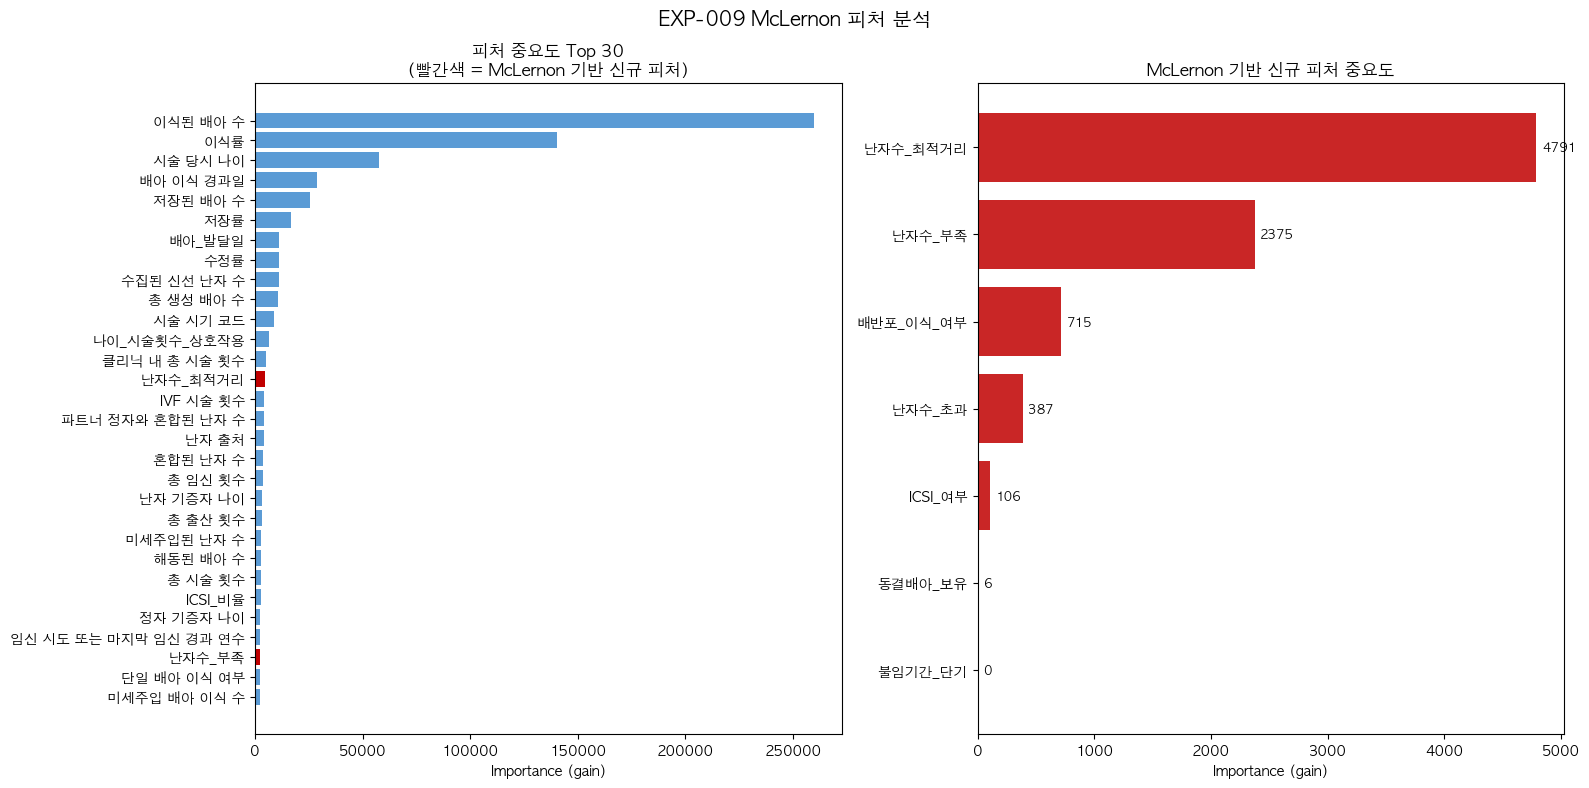

In [10]:
importance = pd.Series(importance_gain, index=X_train.columns).sort_values(ascending=False)

# McLernon 피처만 따로 확인
mc_imp = importance[mclernon_features].sort_values(ascending=False)
print('=== McLernon 피처 중요도 (gain) ===')
for feat, val in mc_imp.items():
    rank = (importance > val).sum() + 1
    print(f'  {feat:20s}: {val:10.1f}  (전체 {rank}위)')

# 전체 Top 30 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top30 = importance.head(30)
colors = ['#C00000' if f in mclernon_features else '#5B9BD5' for f in top30.index[::-1]]
axes[0].barh(top30.index[::-1], top30.values[::-1], color=colors)
axes[0].set_title('피처 중요도 Top 30\n(빨간색 = McLernon 기반 신규 피처)', fontsize=12)
axes[0].set_xlabel('Importance (gain)')

mc_imp_plot = mc_imp.sort_values()
axes[1].barh(mc_imp_plot.index, mc_imp_plot.values, color='#C00000', alpha=0.85)
axes[1].set_title('McLernon 기반 신규 피처 중요도', fontsize=12)
axes[1].set_xlabel('Importance (gain)')
for i, (feat, val) in enumerate(mc_imp_plot.items()):
    axes[1].text(val + mc_imp_plot.max()*0.01, i, f'{val:.0f}', va='center', fontsize=9)

plt.suptitle('EXP-009 McLernon 피처 분석', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Submission 저장 & 실험 기록

In [11]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
sub['probability'] = test_preds
auc_str   = f'{oof_auc:.4f}'.replace('.', '')
out_fname = f'submission_exp{EXP_NO:03d}_{AUTHOR}_{auc_str}.csv'
sub.to_csv(OUT_DIR / out_fname, index=False)
print(f'저장: {OUT_DIR / out_fname}')

저장: ../data/submissions/submission_exp009_조여진_07387.csv


In [12]:
def log_to_leaderboard(exp_no, author, model_name, params_str,
                        f1, recall, precision, accuracy, oof_auc, oof_prauc, oof_f1_score,
                        cv_strategy, preprocessing_ver, n_features,
                        imbalance_method, submitted, hackathon_score,
                        file_name, notes='', insights=''):
    from openpyxl import load_workbook
    from openpyxl.styles import Font, Alignment, Border, Side, PatternFill
    lb_path = DOCS_DIR / 'leaderboard.xlsx'
    wb = load_workbook(lb_path)
    ws = wb['리더보드']
    exp_label = f'EXP-{exp_no:03d}'
    next_row = ws.max_row + 1
    for r in range(2, ws.max_row + 1):
        val = ws.cell(row=r, column=2).value
        if val == exp_label:
            next_row = r; break
        if ws.cell(row=r, column=1).value is None or str(ws.cell(row=r, column=1).value).strip() == '':
            next_row = r; break
    values = [str(date.today()), exp_label, author, model_name, params_str,
              round(f1,5), round(recall,5), round(precision,5), round(accuracy,5), round(oof_auc,5),
              cv_strategy, preprocessing_ver, n_features, imbalance_method,
              submitted, hackathon_score, file_name, notes, insights]
    thin = Side(style='thin', color='B0B8D0')
    border = Border(left=thin, right=thin, top=thin, bottom=thin)
    fill = PatternFill('solid', fgColor='EEF2FA') if next_row % 2 == 0 else None
    font = Font(name='맑은 고딕', size=10)
    center = Alignment(horizontal='center', vertical='center', wrap_text=True)
    left   = Alignment(horizontal='left',   vertical='center', wrap_text=True)
    left_cols = {4, 5, 12, 14, 17, 18, 19}
    for c_idx, val in enumerate(values, start=1):
        cell = ws.cell(row=next_row, column=c_idx, value=val)
        cell.font = font; cell.border = border
        cell.alignment = left if c_idx in left_cols else center
        if fill: cell.fill = fill
        if c_idx in range(6, 11) or c_idx == 16: cell.number_format = '0.00000'
    wb.save(lb_path)
    print(f'[leaderboard.xlsx] EXP-{exp_no:03d} 기록 완료 (row {next_row})')

oof_binary = (oof_preds >= 0.5).astype(int)
params_str = 'num_leaves=127, lr=0.05, feature_fraction=0.8, McLernon 피처 7개 추가'
NOTES    = 'McLernon 2016(BMJ) 기반 피처 7개 추가: 난자수 비선형(최적 13개), 배반포이식, 동결배아보유, ICSI여부, 불임기간단기'
INSIGHTS = ''

log_to_leaderboard(
    EXP_NO, AUTHOR, MODEL_NAME, params_str,
    f1_score(y_train, oof_binary), recall_score(y_train, oof_binary),
    precision_score(y_train, oof_binary), accuracy_score(y_train, oof_binary),
    oof_auc, oof_prauc, oof_f1,
    CV_STR, 'v1+McLernon', X_train.shape[1], 'is_unbalance=True',
    'N', None, 'notebooks/08_mclernon_yjcho.ipynb', NOTES, INSIGHTS
)

[leaderboard.xlsx] EXP-009 기록 완료 (row 9)
